In [1]:
# --- CELL 1: SETUP & LIBRARIES ---
!pip install boruta -q

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Boruta & ML
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, cohen_kappa_score, roc_curve, auc, precision_recall_curve

# Deep Learning
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Activation, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

sns.set_style("whitegrid")
print(" Kütüphaneler Hazır.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.6 MB/s eta 0:00:00
 Kütüphaneler Hazır.


In [2]:
# --- CELL 2: DATA PREPARATION ---
print(" Veri Yükleniyor ve Hazırlanıyor...")
df = pd.read_csv("urban_building_stock_datasets_17042024.csv")

# 1. Leakage (Sızıntı) Sütunlarını Temizle
leakage_cols = ['Total_Heating_Energy', 'Interior_Lighting_Energy', 'Interior_Equipment_Energy',
                'Heating_Energy', 'Photovoltaic_Power', 'Total_Electricity_Energy',
                'Energy_Use_Intensity', 'Water_Systems_Energy', 'Building_Energy_Rating',
                'Electricity_Primary_Conversion_Factor', 'Heating_Primary_Conversion_Factor']
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

target = "Simple_Building_Energy_Rating"
X = df.drop(columns=[target])
y = df[target].copy()

# 2. Feature Engineering (Yeni Özellikler Türetme)
X["Global_U_Value"] = (X["Window_Insulation_U-Value"] * X["Window_to_Wall_Ratio"] +
                       X["Wall_Insulation_U-Value"] * (1 - X["Window_to_Wall_Ratio"]))
X["Thermostat_Delta"] = X["Heating_Setpoint_Temperature"] - X["Heating_Setback_Temperature"]
X["Internal_Load_Score"] = (X["Lighting_Density"] + X["Equipment_Density"] +
                            (X["Occupancy_Level"] * 100 / (X["Total_Building_Area"] + 1)))
X["HVAC_Load_Factor"] = X["Total_Building_Area"] / (X["HVAC_Efficiency"] + 0.1)
X["Infiltration_Loss_Potential"] = (X["Air_Change_Rate"] * X["Total_Building_Area"] * X["Thermostat_Delta"])
X["Weighted_Roof_U"] = X["Total_Building_Area"] * X["Roof_Insulation_U-Value"]
X["Orientation_Sin"] = np.sin(np.deg2rad(X["Building_Orientation"]))
X["Orientation_Cos"] = np.cos(np.deg2rad(X["Building_Orientation"]))
X = X.drop(columns=["Building_Orientation"])

# 3. Preprocessing (Ön İşleme)
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", MinMaxScaler())]), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
], verbose_feature_names_out=False)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_
n_classes = len(classes)

# 4. Split (Eğitim/Test Ayrımı - %80 Train, %20 Test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# 5. Transform
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)
y_train_oh = to_categorical(y_train, n_classes)
y_test_oh = to_categorical(y_test, n_classes)

feature_names = preprocessor.get_feature_names_out()

print(f" Veri Hazır: {X_train.shape} (Satır, Sütun)")
print(f" Toplam Özellik Sayısı: {len(feature_names)}")

 Veri Yükleniyor ve Hazırlanıyor...
 Veri Hazır: (838849, 31) (Satır, Sütun)
 Toplam Özellik Sayısı: 31


In [4]:
# --- CELL 3: BORUTAPY SELECTION (10% DATA, 200 ITER) ---
!pip install boruta -q
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
import time
import numpy as np

print("\n🔍 BorutaPy Özellik Seçimi Başlıyor (10% Veri, 200 Iteration)...")
start_boruta = time.time()

# 1. ÖRNEKLEM SEÇİMİ (%10)
# Kullanıcı isteği: Verinin %10'u kullanılacak
sample_size = int(len(X_train) * 0.10)
idx = np.random.choice(len(X_train), sample_size, replace=False)
X_sample = X_train[idx]
y_sample = y_train[idx]

print(f"ℹ️ Seçim için kullanılan örneklem boyutu: {X_sample.shape}")

# 2. RANDOM FOREST AYARLARI
# Hız için max_depth=5 idealdir. class_weight='balanced' dengesizliği yönetir.
rf = RandomForestClassifier(
    n_jobs=-1,
    class_weight='balanced',
    max_depth=5,
    random_state=42
)

# 3. BORUTA BAŞLATMA
# Kullanıcı isteği: max_iter=200
boruta = BorutaPy(
    estimator=rf,
    n_estimators='auto',
    verbose=2,       # İlerleme detaylarını gösterir
    random_state=42,
    max_iter=200     # İterasyon sayısı 200'e çıkarıldı
)

# 4. EĞİTİMİ BAŞLAT
boruta.fit(X_sample, y_sample)

# 5. SONUÇLARI KAYDET
mask_boruta = boruta.support_
selected_features_boruta = feature_names[mask_boruta]
boruta_runtime = time.time() - start_boruta

print(f"\n✅ Boruta Tamamlandı.")
print(f"⏱️ Süre: {boruta_runtime/60:.2f} dk")
print(f"🎯 Seçilen Özellik Sayısı: {len(selected_features_boruta)}")
print("\n[Source: 6] Boruta Tarafından Seçilen Özellikler:")
print(list(selected_features_boruta))


🔍 BorutaPy Özellik Seçimi Başlıyor (10% Veri, 200 Iteration)...
ℹ️ Seçim için kullanılan örneklem boyutu: (83884, 31)
Iteration: 	1 / 200
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	2 / 200
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	3 / 200
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	4 / 200
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	5 / 200
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	6 / 200
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	7 / 200
Confirmed: 	0
Tentative: 	31
Rejected: 	0
Iteration: 	8 / 200
Confirmed: 	28
Tentative: 	0
Rejected: 	3


BorutaPy finished running.

Iteration: 	9 / 200
Confirmed: 	28
Tentative: 	0
Rejected: 	3

✅ Boruta Tamamlandı.
⏱️ Süre: 1.14 dk
🎯 Seçilen Özellik Sayısı: 28

[Source: 6] Boruta Tarafından Seçilen Özellikler:
['Floor_Insulation_U-Value', 'Door_Insulation_U-Value', 'Roof_Insulation_U-Value', 'Window_Insulation_U-Value', 'Wall_Insulation_U-Value', 'HVAC_Efficiency', 'Domestic_Hot_Wa

In [5]:
# --- CELL 4: FINAL TRAINING (RESNET WITH BORUTA FEATURES) ---
print("\n Final Model Eğitimi (Boruta Özellikleri + Optuna Parametreleri)...")
train_start = time.time()

# 1. Veri Setini Güncelle (Sadece Boruta'nın seçtiği sütunlar)
if 'mask_boruta' in globals():
    X_train_boruta = X_train[:, mask_boruta]
    X_test_boruta = X_test[:, mask_boruta]
    print(f" Özellik Sayısı İndirgendi: {X_train.shape[1]} -> {X_train_boruta.shape[1]}")
else:
    print(" UYARI: mask_boruta bulunamadı, tüm veriyi kullanıyorum.")
    X_train_boruta = X_train
    X_test_boruta = X_test

# 2. ResNet Model (Focal Loss & Optuna Params)
def categorical_focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * y_true * tf.math.pow((1 - y_pred), gamma)
        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=1)
    return focal_loss_fixed

def build_resnet_optuna(input_dim):
    input_layer = Input(shape=(input_dim,))

    # --- OPTUNA PARAMETRELERİ ---
    UNITS = 512          # Optuna'dan gelen en iyi nöron sayısı
    N_LAYERS = 4         # Optuna'dan gelen katman sayısı
    ACTIVATION = 'relu'
    DROPOUT = 0.1
    LR = 0.0002053081101089717 # Optuna'dan gelen learning rate

    # Giriş Bloğu
    x = Dense(UNITS, kernel_regularizer=l2(0.0001))(input_layer)
    x = BatchNormalization()(x)
    x = Activation(ACTIVATION)(x)
    x = Dropout(DROPOUT)(x)

    # Residual Bloklar
    for _ in range(N_LAYERS):
        shortcut = x
        # Blok İçi (Boyutlar Eşit: 512)
        x = Dense(UNITS, kernel_regularizer=l2(0.0001))(x)
        x = BatchNormalization()(x)
        x = Activation(ACTIVATION)(x)
        x = Dropout(DROPOUT)(x)

        # Skip Connection (512 + 512)
        x = Add()([x, shortcut])
        x = Activation(ACTIVATION)(x)

    output_layer = Dense(n_classes, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    opt = Adam(learning_rate=LR)
    model.compile(loss=categorical_focal_loss(), optimizer=opt, metrics=['accuracy'])
    return model

# Modeli Kur
final_model_boruta = build_resnet_optuna(X_train_boruta.shape[1])

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    ModelCheckpoint("boruta_final_model.keras", save_best_only=True, monitor='val_accuracy', mode='max')
]

# Eğit (Tam Veri Seti ile)
history_boruta = final_model_boruta.fit(
    X_train_boruta, y_train_oh,
    validation_data=(X_test_boruta, y_test_oh),
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

boruta_train_time = time.time() - train_start
print(f" Eğitim Süresi: {boruta_train_time/60:.2f} dk")


 Final Model Eğitimi (Boruta Özellikleri + Optuna Parametreleri)...
 Özellik Sayısı İndirgendi: 31 -> 28
Epoch 1/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.6805 - loss: 0.2870 - val_accuracy: 0.7864 - val_loss: 0.1314 - learning_rate: 2.0531e-04
Epoch 2/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.7568 - loss: 0.1170 - val_accuracy: 0.7727 - val_loss: 0.0683 - learning_rate: 2.0531e-04
Epoch 3/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.7774 - loss: 0.0656 - val_accuracy: 0.8028 - val_loss: 0.0503 - learning_rate: 2.0531e-04
Epoch 4/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.7858 - loss: 0.0542 - val_accuracy: 0.8141 - val_loss: 0.0448 - learning_rate: 2.0531e-04
Epoch 5/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.7914 - loss: 0.0502 - val_accuracy: 0.8082 - val_loss: 0.0434 - learning_rate: 2.0531e-04
Epoch 6/100
3277/3277 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.7932 - loss: 0.0483 - va

6554/6554 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step

--- Classification Report (Boruta Features) ---
              precision    recall  f1-score   support

           A     0.9615    0.9462    0.9538     43777
           B     0.9092    0.8911    0.9001     54258
           C     0.8770    0.8926    0.8847     54852
           D     0.8026    0.8213    0.8119     26453
           E     0.7615    0.7692    0.7653     14131
           F     0.6823    0.6503    0.6659      6655
           G     0.8862    0.9188    0.9022      9587

    accuracy                         0.8796    209713
   macro avg     0.8400    0.8414    0.8406    209713
weighted avg     0.8800    0.8796    0.8797    209713



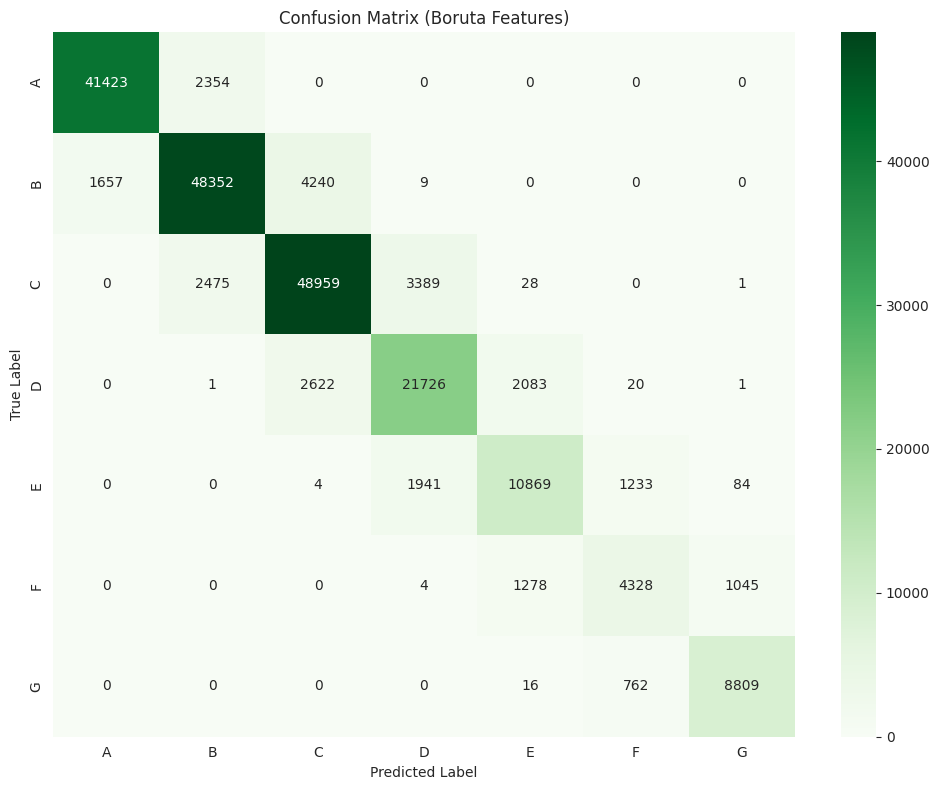

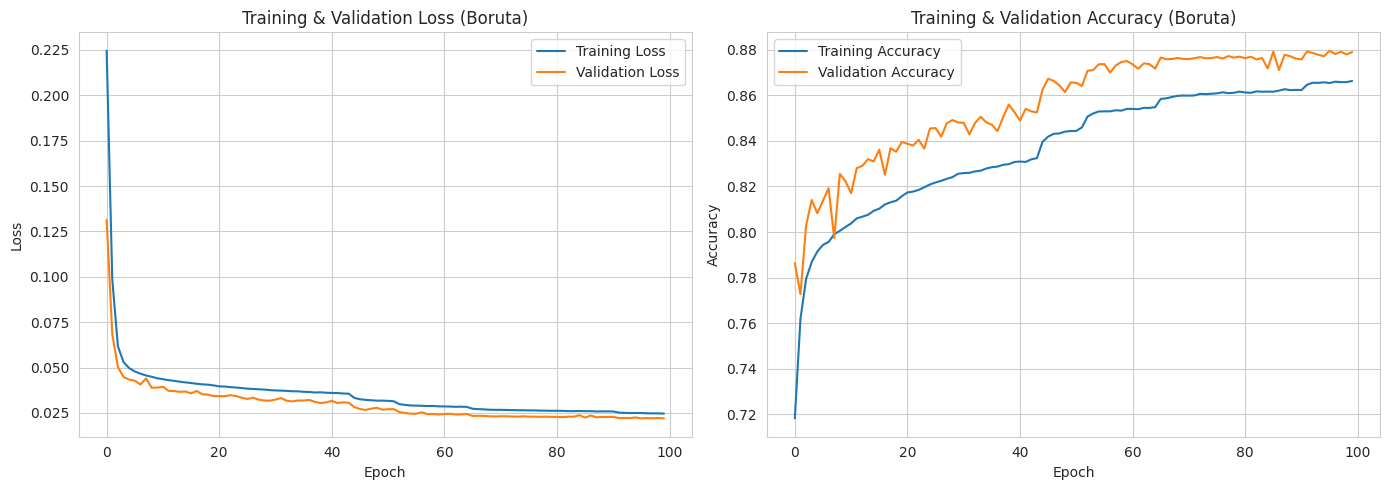


Test Set Accuracy Rate: %87.96
Cohen's Kappa Score: 0.8491


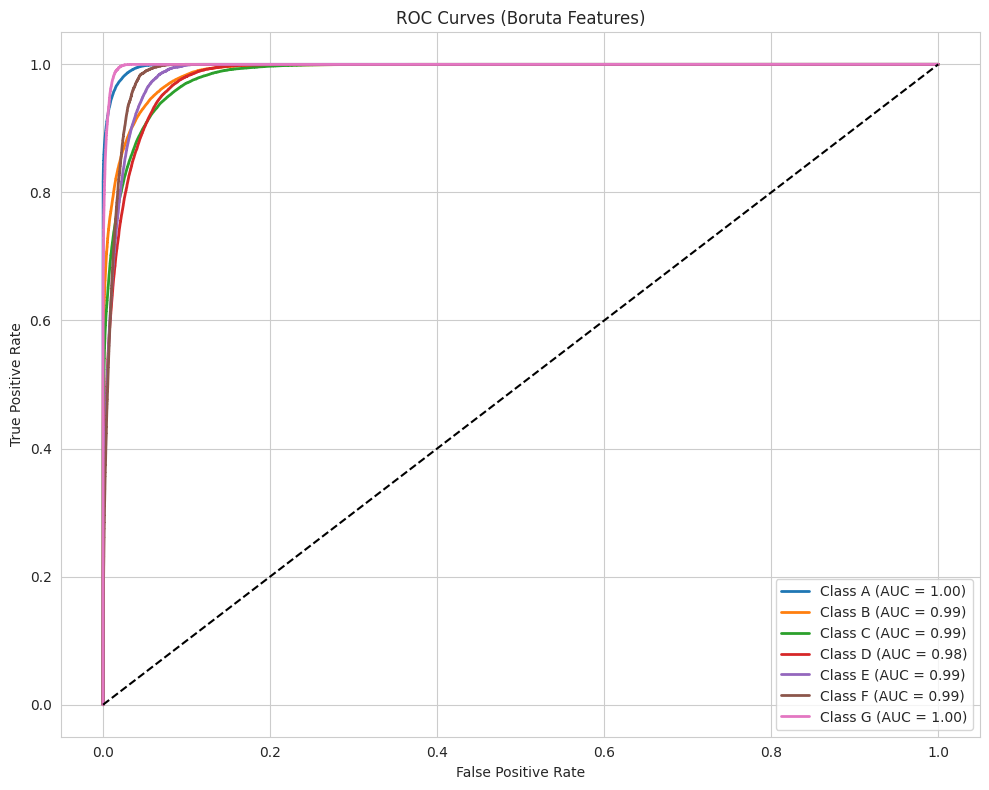

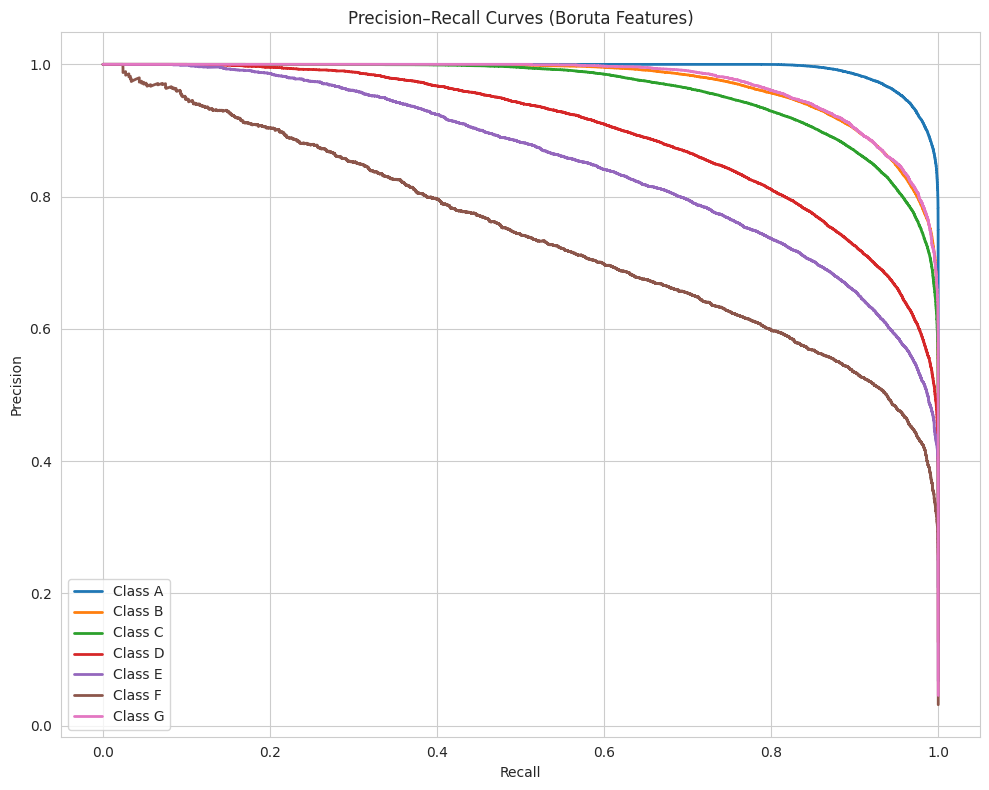

In [8]:
# --- CELL 5: REPORTING & PLOTS (BORUTA) ---
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    cohen_kappa_score,
    roc_curve,
    auc,
    precision_recall_curve
)
from sklearn.preprocessing import label_binarize

# --------------------------------------------------
# Predictions
# --------------------------------------------------
y_pred_probs = final_model_boruta.predict(X_test_boruta)
y_pred = np.argmax(y_pred_probs, axis=1)

# ==================================================
# 1. CLASSIFICATION REPORT (DÜZGÜN SKLEARN FORMAT)
# ==================================================
print("\n--- Classification Report (Boruta Features) ---")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=classes,
        digits=4
    )
)

# ==================================================
# 2. CONFUSION MATRIX
# ==================================================
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=classes,
    yticklabels=classes
)
plt.title('Confusion Matrix (Boruta Features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# ==================================================
# 3. TRAINING / VALIDATION CURVES
# ==================================================
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_boruta.history['loss'], label='Training Loss')
plt.plot(history_boruta.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss (Boruta)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_boruta.history['accuracy'], label='Training Accuracy')
plt.plot(history_boruta.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy (Boruta)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# ==================================================
# 4. ACCURACY & COHEN'S KAPPA
# ==================================================
test_acc = accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

print(f"\nTest Set Accuracy Rate: %{test_acc*100:.2f}")
print(f"Cohen's Kappa Score: {kappa:.4f}")

# ==================================================
# 5. ROC & PRECISION–RECALL CURVES
# ==================================================
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# ---------- ROC CURVES ----------
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves (Boruta Features)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ---------- PRECISION–RECALL CURVES ----------
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_pred_probs[:, i]
    )
    plt.plot(recall, precision, lw=2, label=f'Class {classes[i]}')

plt.title('Precision–Recall Curves (Boruta Features)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc="best")
plt.tight_layout()
plt.show()
